# A Simple Example of Clustering 

You are given much more country data. Using the same methodology as the one in the lecture, group all the countries in 2 clusters. 

Try with other numbers of clusters and see if they match your expectations. Maybe 7 is going to be a cool one!

Plot the data using the <i> c </i> parameter to separate the data by the clusters we defined.  

<i> Note: c stands for color <i>

## Import the relevant libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn
seaborn.set_theme()

## Load the data

Load data from the csv file: <i> 'Countries.csv'</i>.


In [3]:
raw_data = pd.read_csv('Countries-exercise.csv')
raw_data

,name,Longitude,Latitude
0,Aruba,-69.982677,12.520880
1,Afghanistan,66.004734,33.835231
2,Angola,17.537368,-12.293361
3,Anguilla,-63.064989,18.223959
4,Albania,20.049834,41.142450
...,...,...,...
236,Samoa,-172.164851,-13.753243
237,Yemen,47.586762,15.909280
238,South Africa,25.083901,-29.000341
239,Zambia,27.774759,-13.458242


## Plot the data

Plot the <i>'Longtitude'</i> and <i>'Latitude'</i> columns. 

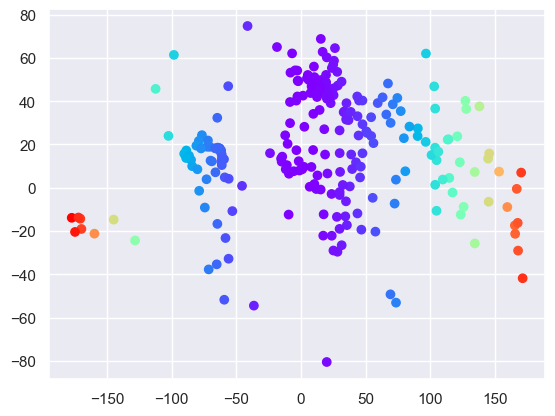

In [4]:
plt.scatter(raw_data['Longitude'],raw_data['Latitude'],c=raw_data['Longitude']*raw_data['Longitude'], cmap='rainbow')

## Select the features

Create a copy of that data and remove all parameters apart from <i>Longitude</i> and <i>Latitude</i>.

In [5]:
location=raw_data.loc[:, ['Longitude', 'Latitude']]
location

,Longitude,Latitude
0,-69.982677,12.520880
1,66.004734,33.835231
2,17.537368,-12.293361
3,-63.064989,18.223959
4,20.049834,41.142450
...,...,...
236,-172.164851,-13.753243
237,47.586762,15.909280
238,25.083901,-29.000341
239,27.774759,-13.458242


## Clustering

Assume there are only two clusters. 

In [6]:
kmeans=KMeans(8)

In [7]:
kmeans.fit(location)

,n_clusters,8
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


### Clustering Resutls

In [8]:
clusters = kmeans.fit_predict(location)
clusters

array([3, 4, 7, 3, 1, 1, 1, 4, 0, 4, 5, 7, 6, 7, 3, 2, 1, 4, 7, 1, 7, 7,
       6, 1, 4, 3, 3, 1, 3, 1, 3, 3, 0, 0, 3, 6, 6, 7, 7, 1, 0, 6, 7, 7,
       7, 7, 5, 3, 7, 1, 3, 3, 3, 3, 4, 4, 1, 1, 4, 3, 1, 3, 1, 3, 4, 4,
       1, 1, 4, 1, 2, 0, 1, 1, 2, 7, 1, 4, 1, 7, 7, 7, 7, 7, 1, 3, 1, 3,
       6, 3, 6, 7, 3, 1, 3, 1, 6, 1, 4, 6, 4, 1, 4, 4, 1, 4, 1, 3, 1, 4,
       6, 4, 4, 7, 4, 6, 3, 3, 6, 1, 4, 6, 4, 7, 1, 3, 1, 4, 7, 1, 1, 1,
       6, 3, 1, 1, 1, 7, 4, 3, 2, 1, 1, 1, 6, 1, 6, 6, 7, 1, 3, 7, 7, 6,
       7, 2, 7, 2, 7, 3, 5, 1, 1, 4, 2, 2, 4, 4, 3, 5, 3, 6, 6, 2, 1, 3,
       6, 1, 0, 4, 5, 4, 1, 6, 7, 1, 4, 7, 7, 7, 6, 0, 7, 2, 7, 3, 1, 4,
       4, 3, 1, 7, 3, 1, 1, 1, 7, 3, 4, 4, 3, 7, 7, 6, 4, 4, 6, 5, 3, 1,
       4, 6, 7, 7, 1, 0, 3, 4, 1, 3, 3, 3, 3, 6, 2, 5, 5, 4, 7, 7, 7],
      dtype=int32)

In [9]:
location['Cluster'] = clusters
location

,Longitude,Latitude,Cluster
0,-69.982677,12.520880,3
1,66.004734,33.835231,4
2,17.537368,-12.293361,7
3,-63.064989,18.223959,3
4,20.049834,41.142450,1
...,...,...,...
236,-172.164851,-13.753243,5
237,47.586762,15.909280,4
238,25.083901,-29.000341,7
239,27.774759,-13.458242,7


Did you remember to use the <i> c </i> parameter to separate the data by the clusters we defined?

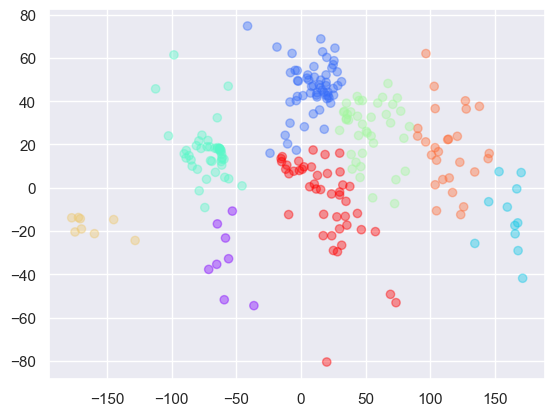

array([[ -58.06867095,  -32.85568251],
       [   9.26180921,   46.25554408],
       [ 160.73641421,  -13.90902112],
       [ -71.80957148,   16.76619969],
       [  52.63131231,   26.54485293],
       [-162.24003412,  -17.71618937],
       [ 114.28557305,   18.04467747],
       [  18.92775333,   -6.09201623]])

In [10]:
plt.scatter(location['Longitude'],location['Latitude'], c=location['Cluster'],cmap='rainbow', alpha=0.4)
plt.show()
kmeans.cluster_centers_

In [24]:
centroids = pd.DataFrame(kmeans.cluster_centers_)
centroids

,0,1
0,-58.068671,-32.855683
1,9.261809,46.255544
2,160.736414,-13.909021
3,-71.809571,16.766200
4,52.631312,26.544853
5,-162.240034,-17.716189
6,114.285573,18.044677
7,18.927753,-6.092016


In [25]:
new_columns=['Longitude','Latitude']
centroids.columns

RangeIndex(start=0, stop=2, step=1)

In [26]:
centroids.columns=new_columns
centroids

,Longitude,Latitude
0,-58.068671,-32.855683
1,9.261809,46.255544
2,160.736414,-13.909021
3,-71.809571,16.766200
4,52.631312,26.544853
5,-162.240034,-17.716189
6,114.285573,18.044677
7,18.927753,-6.092016


In [27]:
centroids['Cluster'] = 8
centroids

,Longitude,Latitude,Cluster
0,-58.068671,-32.855683,8
1,9.261809,46.255544,8
2,160.736414,-13.909021,8
3,-71.809571,16.766200,8
4,52.631312,26.544853,8
5,-162.240034,-17.716189,8
6,114.285573,18.044677,8
7,18.927753,-6.092016,8


If you haven't, go back and play around with the number of clusters. 

Try 3, 7 and 8 and see if the results match your expectations!